# ROC Curve, Calibration, and Additional Analysis

Supplementary analytical outputs:
- ROC Curve with Bootstrap 95% CI
- Precision-Recall Curve
- Calibration plot (Brier Score)
- Threshold sensitivity analysis

In [1]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
from scipy import stats
from scipy.stats import wilcoxon, ttest_rel, mannwhitneyu
from sklearn.metrics import (confusion_matrix, roc_curve, precision_recall_curve, auc, 
                              brier_score_loss, accuracy_score, f1_score, recall_score, 
                              precision_score, cohen_kappa_score)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# Plotting setup
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

# Paths
OUTPUT_BASE = 'folds/folds/output'
FIG_DIR = 'q1_publication_results'
os.makedirs(FIG_DIR, exist_ok=True)
for subdir in ['figures', 'tables', 'supplementary']:
    os.makedirs(os.path.join(FIG_DIR, subdir), exist_ok=True)

print("✓ Setup complete!")

✓ Setup complete!


In [2]:
# Load summary
summary_df = pd.read_csv(os.path.join(OUTPUT_BASE, 'all_folds_runs_summary.csv'))
print(f"Total runs: {len(summary_df)}")
print(f"Unique folds: {summary_df['fold'].nunique()}")
print(f"Runs per fold: {summary_df.groupby('fold').size().tolist()}")

summary_df.head()

Total runs: 50
Unique folds: 5
Runs per fold: [10, 10, 10, 10, 10]


,best_arthrit_boost,best_cls_loss_weight,best_control_boost,best_eval_batch_size,best_focal_gamma,best_lr,best_train_batch_size,best_weight_decay,final_test_loss,final_test_mDice_fg_patient,...,lr_scheduler_type,max_grad_norm,patient_balanced_sampling,pool_alpha,pool_mode,run_idx,search_mean_val_mDice_fg_patient,seed,train_runtime,unfreeze_epoch
0,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.977758,0.827919,...,cosine,1.0,True,1.0,mask,1,0.821892,42,2058.2716,5
1,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.540005,0.823755,...,cosine,1.0,True,1.0,mask,2,0.821892,1042,1128.9786,5
2,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.628001,0.812692,...,cosine,1.0,True,1.0,mask,3,0.821892,2042,1581.7083,5
3,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.315959,0.773808,...,cosine,1.0,True,1.0,mask,4,0.821892,3042,444.4284,5
4,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.957584,0.833754,...,cosine,1.0,True,1.0,mask,5,0.821892,4042,2646.8509,5


In [3]:
# Load all predictions
def load_all_predictions():
    dfs = []
    for fold_dir in sorted(glob.glob(os.path.join(OUTPUT_BASE, 'FOLD_*'))):
        fold = os.path.basename(fold_dir)
        for run_dir in sorted(glob.glob(os.path.join(fold_dir, 'run_*'))):
            run = os.path.basename(run_dir)
            pred_file = os.path.join(run_dir, 'final/fold_test_predictions/predictions.csv')
            if os.path.exists(pred_file):
                df = pd.read_csv(pred_file)
                df['fold'] = fold
                df['run'] = run
                dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

preds_df = load_all_predictions()
print(f"\nTotal predictions: {len(preds_df)}")
print(f"Unique patients: {preds_df['patient_id'].nunique()}")

preds_df.head()


Total predictions: 6550
Unique patients: 503


,image_path,patient_id,total_pixels,positive_pixels,positive_ratio,true_group,cls_head_class,cls_head_prob,arthrit_prob,fold,run
0,folds/folds/FOLD_1/test/darkened/image_005_R_P...,005_R_P_001,786432,21865,0.027803,arthrit,arthrit,1.0,1.0,FOLD_1,run_1
1,folds/folds/FOLD_1/test/darkened/image_005_R_P...,005_R_P_002,786432,27225,0.034618,arthrit,arthrit,1.0,1.0,FOLD_1,run_1
2,folds/folds/FOLD_1/test/darkened/image_005_R_P...,005_R_P_003,786432,27695,0.035216,arthrit,arthrit,1.0,1.0,FOLD_1,run_1
3,folds/folds/FOLD_1/test/darkened/image_005_R_P...,005_R_P_004,786432,24700,0.031408,arthrit,arthrit,1.0,1.0,FOLD_1,run_1
4,folds/folds/FOLD_1/test/darkened/image_005_R_P...,005_R_P_005,786432,53234,0.067691,arthrit,arthrit,1.0,1.0,FOLD_1,run_1


In [4]:
# Aggregate patient-level predictions
valid_preds = preds_df[preds_df['true_group'].isin(['control', 'arthrit'])].copy()

patient_level = valid_preds.groupby(['fold', 'run', 'patient_id']).agg({
    'true_group': 'first',
    'arthrit_prob': 'mean',
    'positive_ratio': 'mean'
}).reset_index()

patient_level['y_true'] = (patient_level['true_group'] == 'arthrit').astype(int)
patient_level['y_pred'] = (patient_level['arthrit_prob'] >= 0.5).astype(int)

print(f"Patient-level data: {len(patient_level)} patients")
patient_level.head()

Patient-level data: 6550 patients


,fold,run,patient_id,true_group,arthrit_prob,positive_ratio,y_true,y_pred
0,FOLD_1,run_1,005_R_P_001,arthrit,1.0,0.027803,1,1
1,FOLD_1,run_1,005_R_P_002,arthrit,1.0,0.034618,1,1
2,FOLD_1,run_1,005_R_P_003,arthrit,1.0,0.035216,1,1
3,FOLD_1,run_1,005_R_P_004,arthrit,1.0,0.031408,1,1
4,FOLD_1,run_1,005_R_P_005,arthrit,1.0,0.067691,1,1


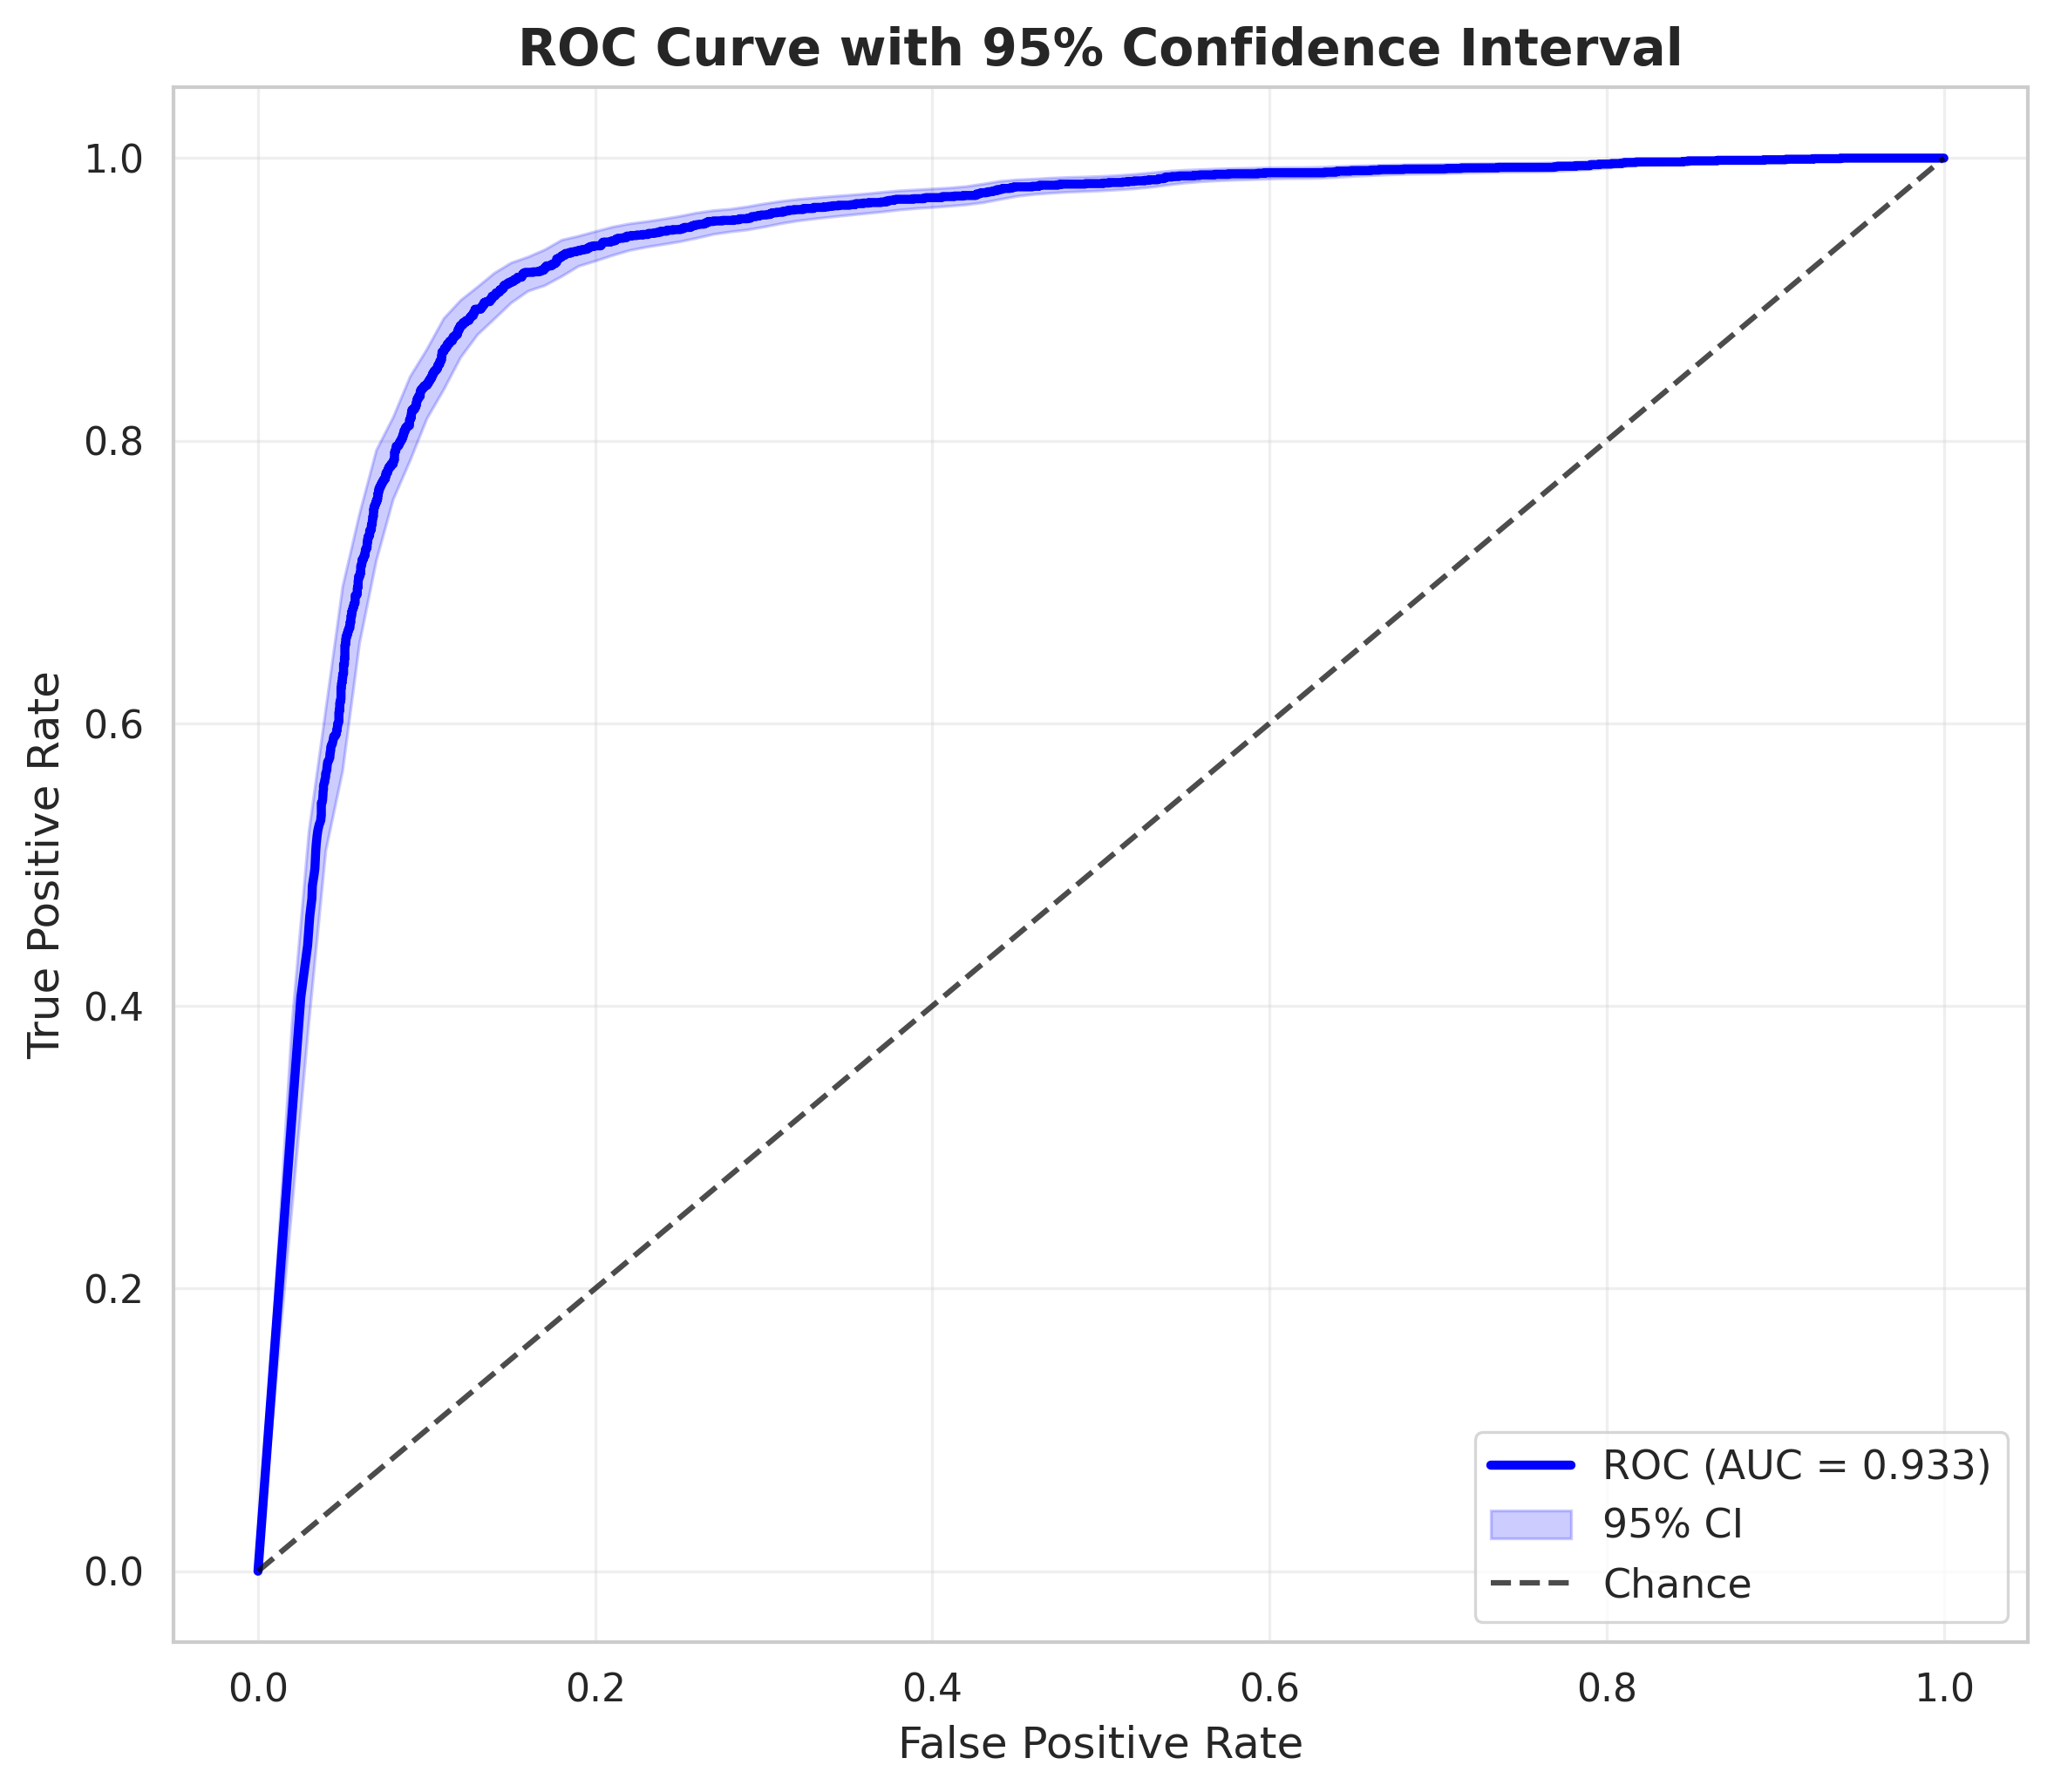

In [11]:
# ROC Curve with Bootstrap CI
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Bootstrap for CI
n_bootstraps = 1000
tprs = []
base_fpr = np.linspace(0, 1, 101)

for i in range(n_bootstraps):
    indices = resample(np.arange(len(y_true)), random_state=i)
    if len(np.unique(y_true[indices])) < 2:
        continue
    fpr_boot, tpr_boot, _ = roc_curve(y_true[indices], y_score[indices])
    tpr_interp = np.interp(base_fpr, fpr_boot, tpr_boot)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

tprs = np.array(tprs)
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, 'b-', lw=2.5, label=f'ROC (AUC = {roc_auc:.3f})')
ax.fill_between(base_fpr, mean_tpr - 1.96*std_tpr, mean_tpr + 1.96*std_tpr, 
               alpha=0.2, color='blue', label='95% CI')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Chance', alpha=0.7)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve with 95% Confidence Interval', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'figures/roc_curve_with_ci.png'), dpi=300, bbox_inches='tight')
plt.show()

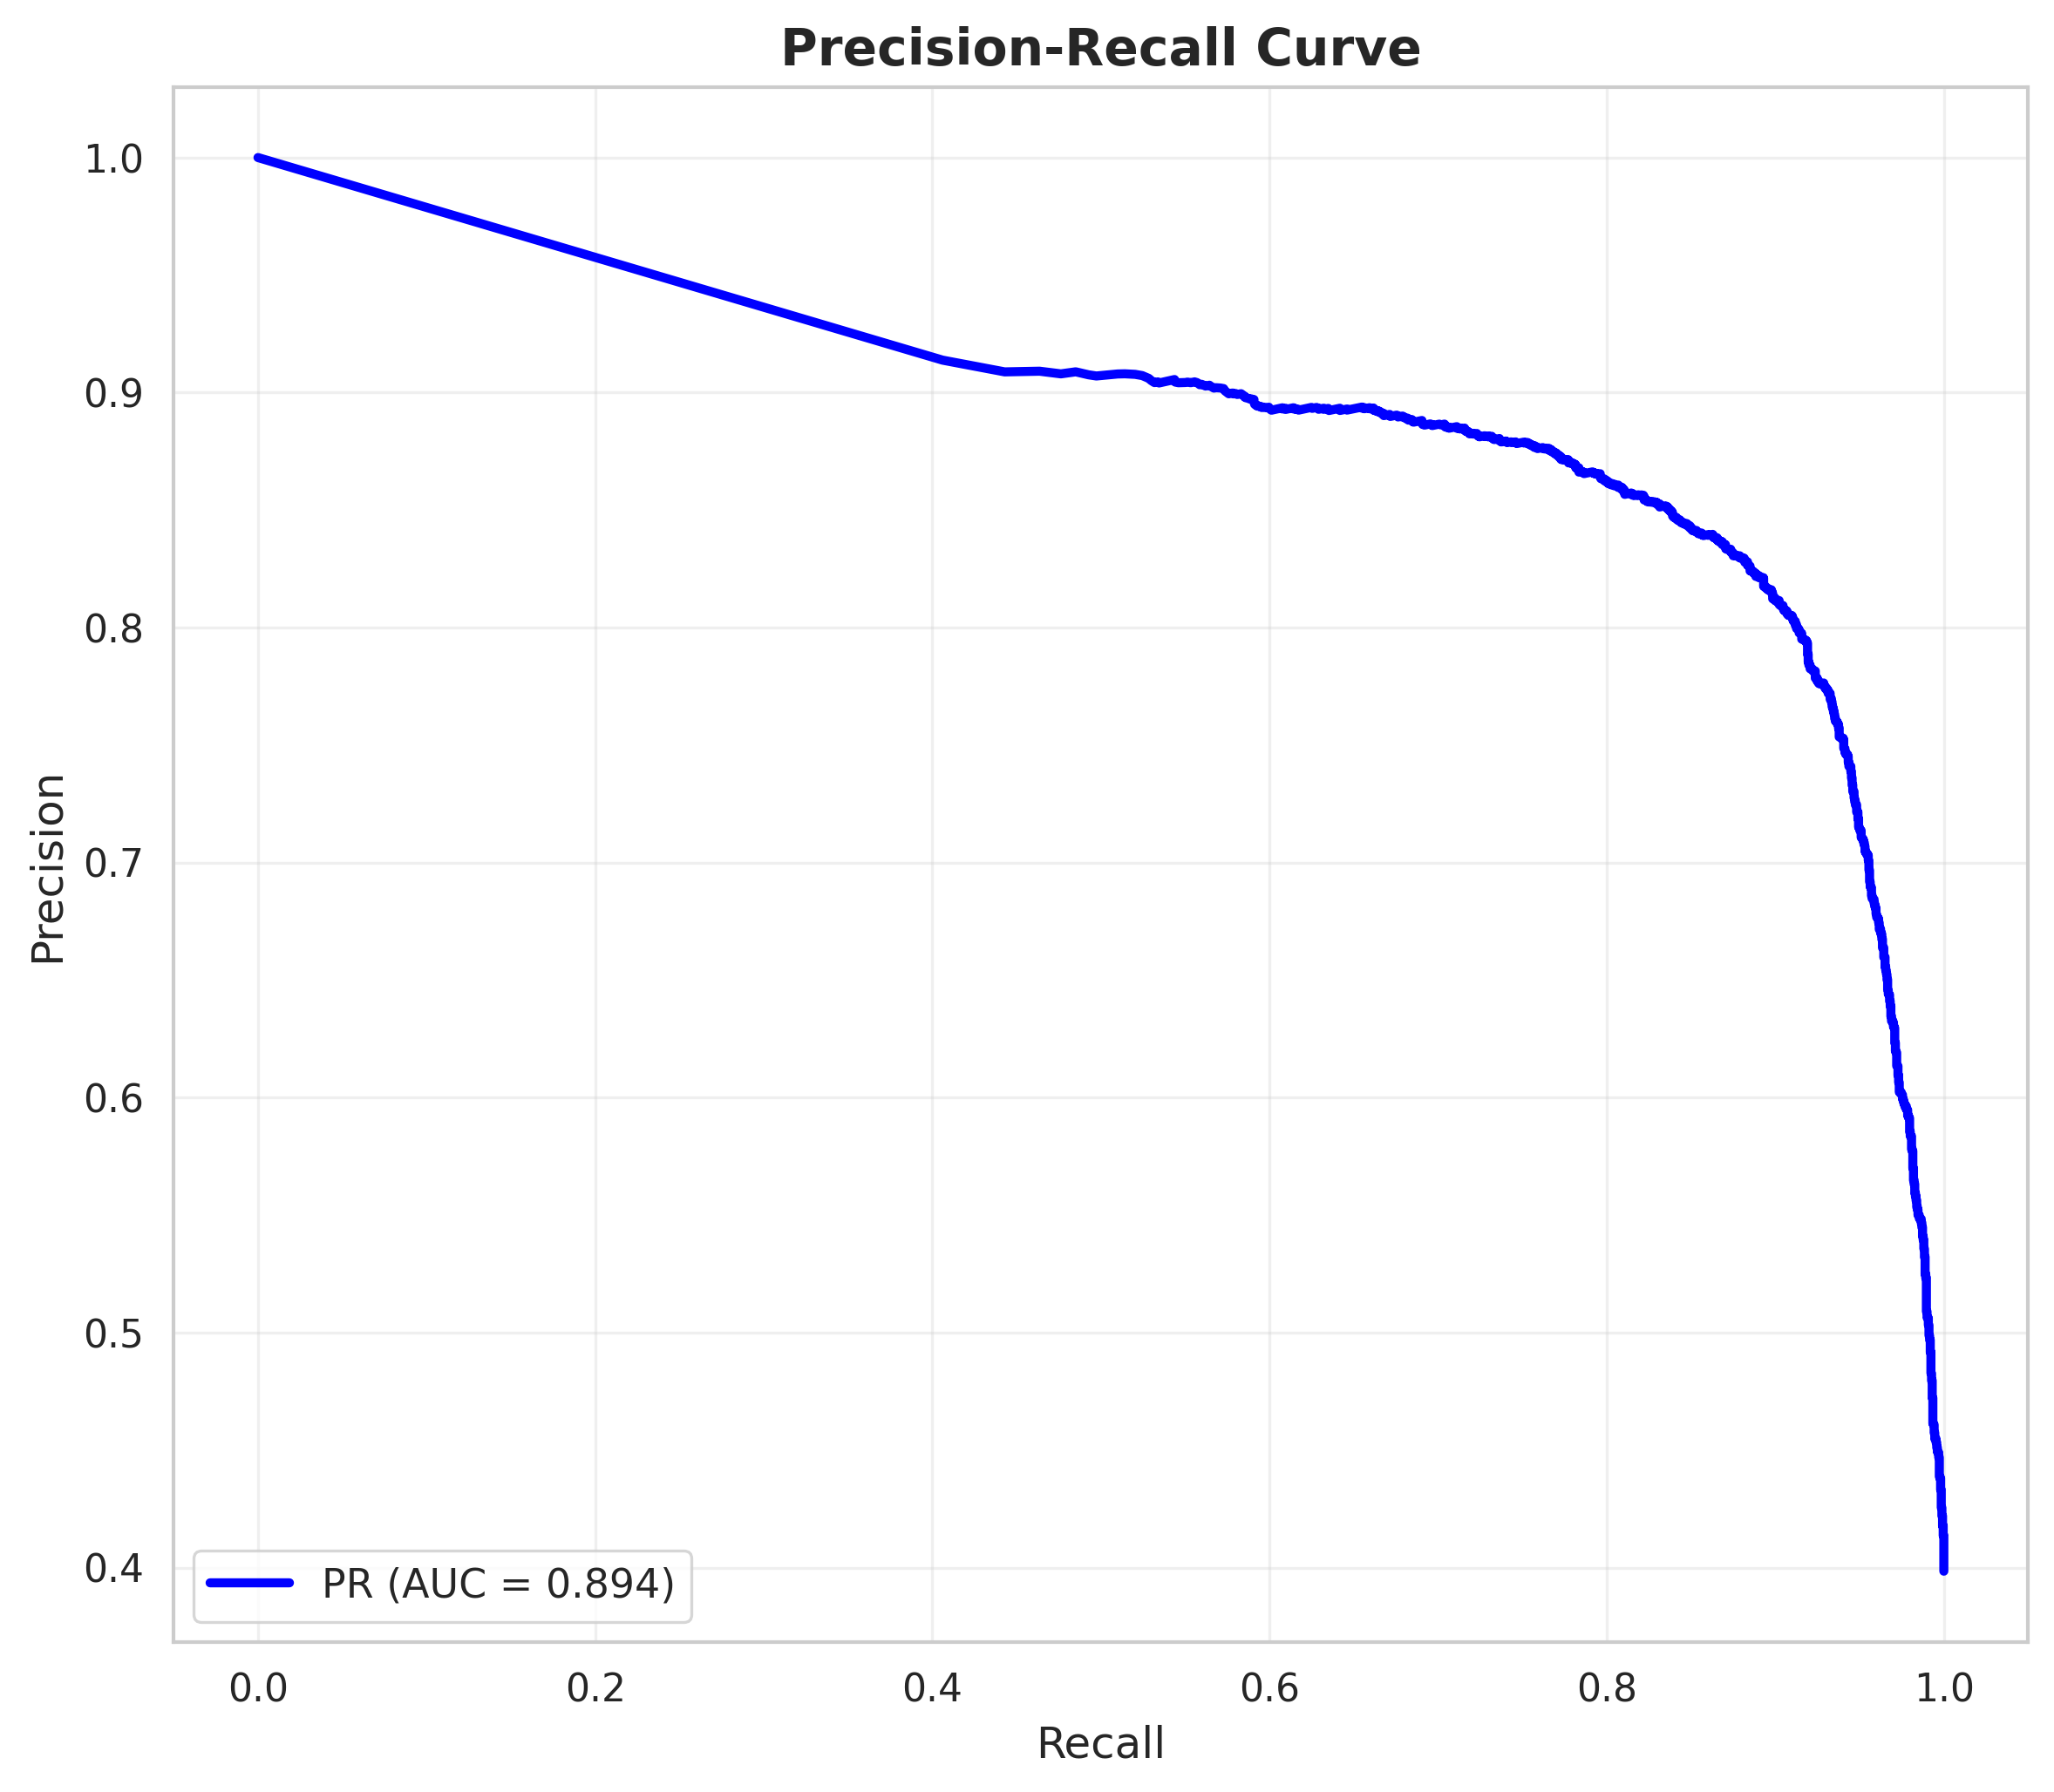

In [12]:
# PR Curve
precision, recall, _ = precision_recall_curve(y_true, y_score)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(recall, precision, 'b-', lw=2.5, label=f'PR (AUC = {pr_auc:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'figures/pr_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

Brier Score: 0.1142
Expected Calibration Error (ECE): 0.5903


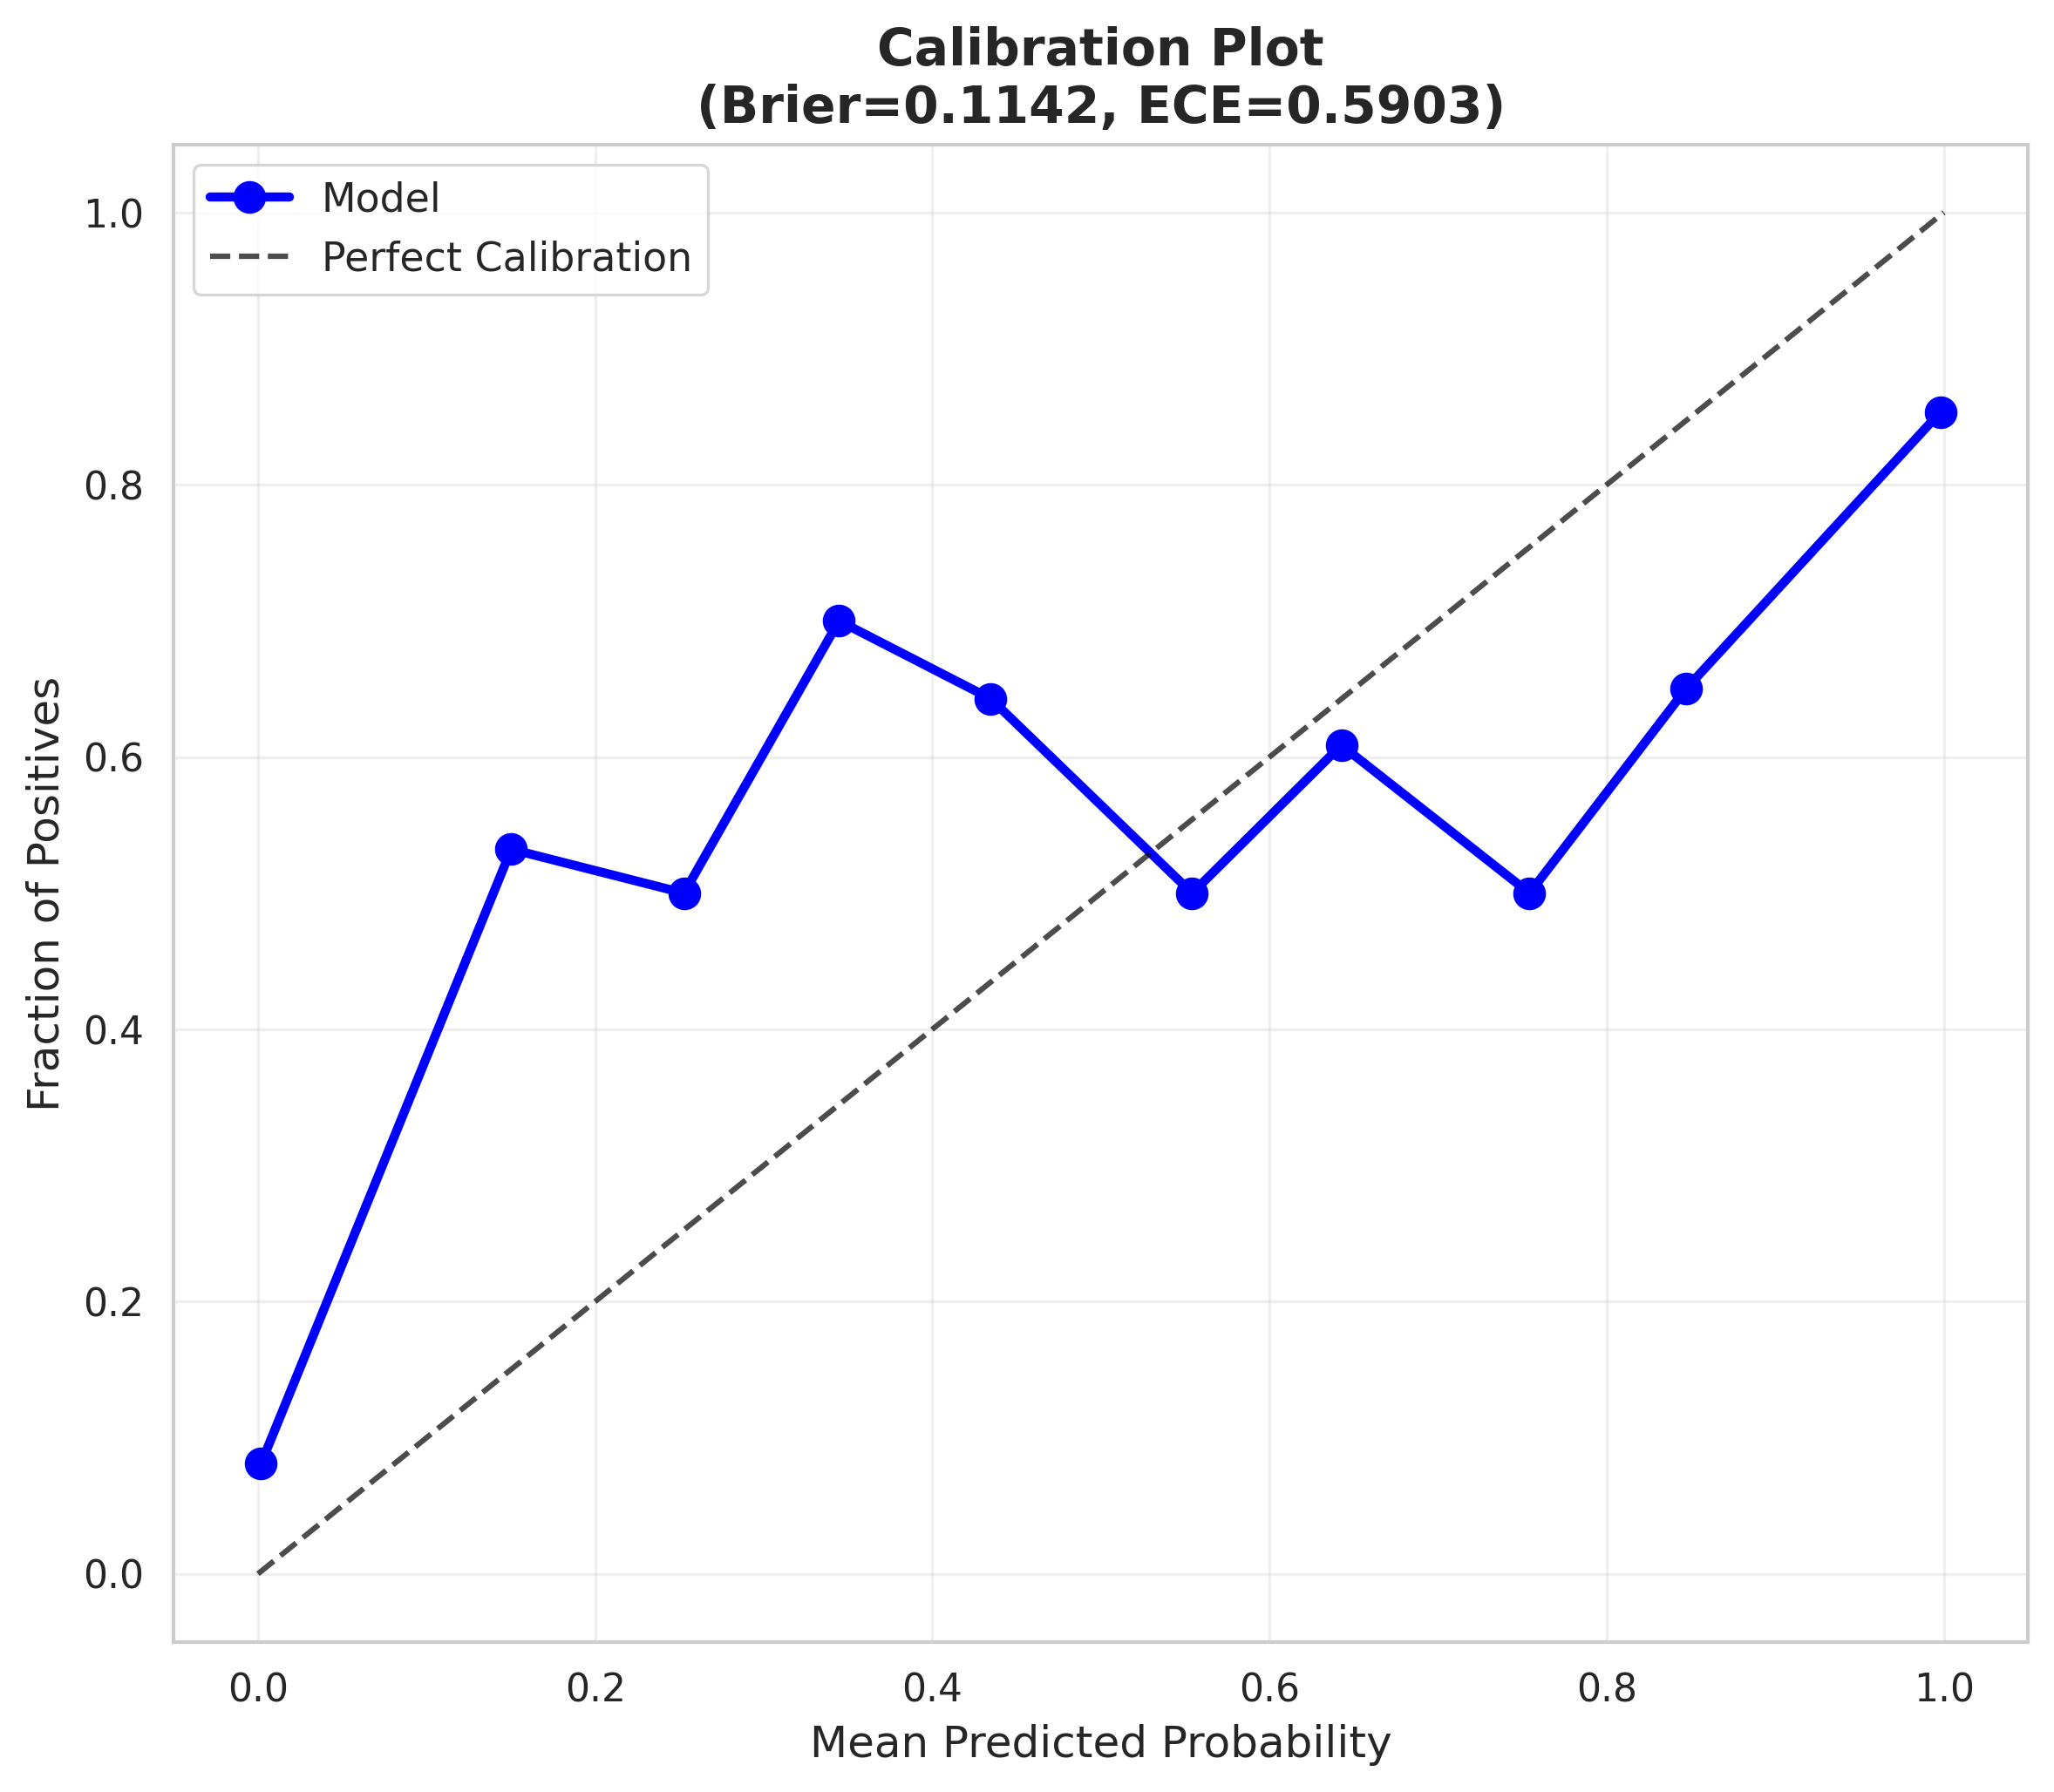

In [14]:
# Brier Score
brier = brier_score_loss(y_true, y_score)

# ECE calculation
def compute_ece(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (y_prob > bin_boundaries[i]) & (y_prob <= bin_boundaries[i+1])
        prop = np.mean(in_bin)
        if prop > 0:
            acc = np.mean(y_true[in_bin] == (y_prob[in_bin] > 0.5))
            conf = np.mean(y_prob[in_bin])
            ece += np.abs(acc - conf) * prop
    return ece

ece = compute_ece(y_true, y_score)

print(f"Brier Score: {brier:.4f}")
print(f"Expected Calibration Error (ECE): {ece:.4f}")

# Calibration curve
fraction_pos, mean_pred = calibration_curve(y_true, y_score, n_bins=10)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(mean_pred, fraction_pos, 'bo-', lw=2.5, markersize=8, label='Model')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect Calibration', alpha=0.7)
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title(f'Calibration Plot\n(Brier={brier:.4f}, ECE={ece:.4f})', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'figures/calibration_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

# Save metrics
cal_metrics = pd.DataFrame([{
    'Brier Score': f'{brier:.4f}',
    'ECE': f'{ece:.4f}'
}])
cal_metrics.to_csv(os.path.join(FIG_DIR, 'tables/calibration_metrics.csv'), index=False)

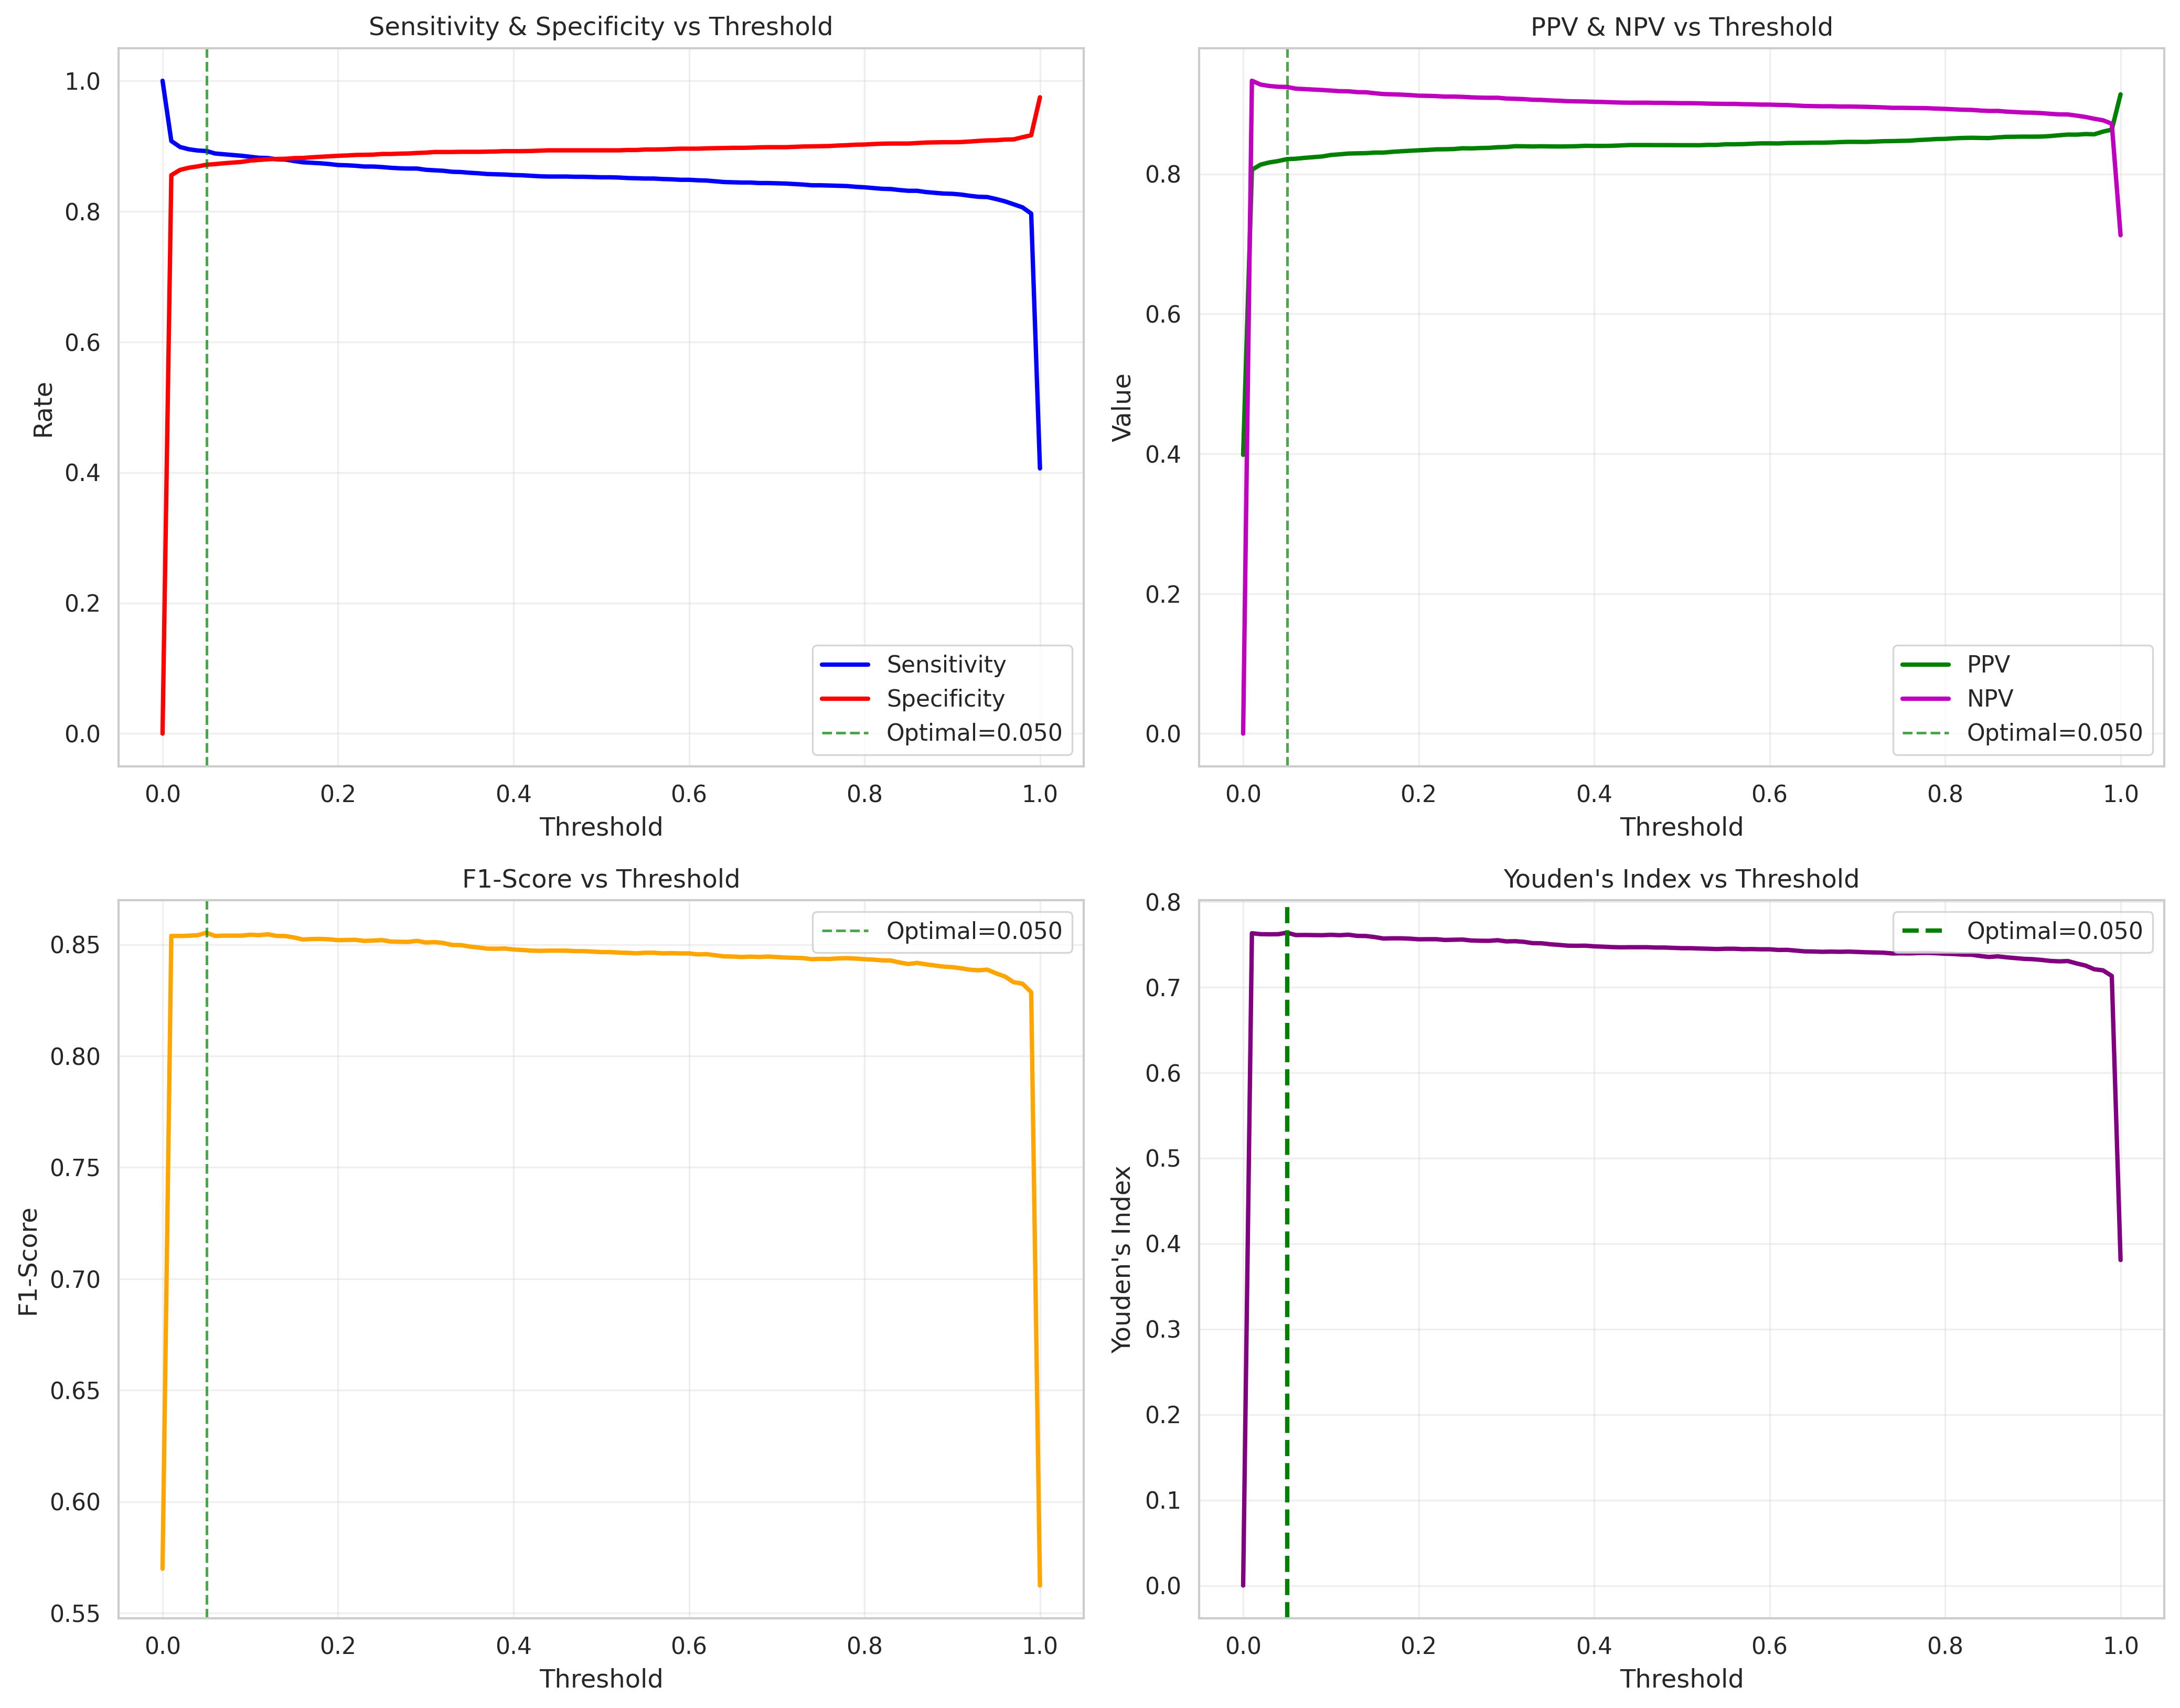


Optimal Threshold Results:
Optimal Threshold  0.050
Sensitivity        0.892
Specificity        0.871
PPV                0.821
NPV                0.924
F1-Score           0.855
Youden Index       0.764


In [16]:
# Threshold sensitivity
thresholds = np.linspace(0, 1, 101)
sensitivities = []
specificities = []
ppvs = []
npvs = []
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_score >= thresh).astype(int)
    
    tp = np.sum((y_true == 1) & (y_pred_thresh == 1))
    tn = np.sum((y_true == 0) & (y_pred_thresh == 0))
    fp = np.sum((y_true == 0) & (y_pred_thresh == 1))
    fn = np.sum((y_true == 1) & (y_pred_thresh == 0))
    
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1 = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
    
    sensitivities.append(sens)
    specificities.append(spec)
    ppvs.append(ppv)
    npvs.append(npv)
    f1_scores.append(f1)

# Youden's Index
youden = np.array(sensitivities) + np.array(specificities) - 1
best_idx = np.argmax(youden)
best_thresh = thresholds[best_idx]

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

axes[0,0].plot(thresholds, sensitivities, 'b-', lw=2, label='Sensitivity')
axes[0,0].plot(thresholds, specificities, 'r-', lw=2, label='Specificity')
axes[0,0].axvline(best_thresh, color='green', linestyle='--', alpha=0.7, label=f'Optimal={best_thresh:.3f}')
axes[0,0].set_xlabel('Threshold')
axes[0,0].set_ylabel('Rate')
axes[0,0].set_title('Sensitivity & Specificity vs Threshold')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(thresholds, ppvs, 'g-', lw=2, label='PPV')
axes[0,1].plot(thresholds, npvs, 'm-', lw=2, label='NPV')
axes[0,1].axvline(best_thresh, color='green', linestyle='--', alpha=0.7, label=f'Optimal={best_thresh:.3f}')
axes[0,1].set_xlabel('Threshold')
axes[0,1].set_ylabel('Value')
axes[0,1].set_title('PPV & NPV vs Threshold')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

axes[1,0].plot(thresholds, f1_scores, 'orange', lw=2)
axes[1,0].axvline(best_thresh, color='green', linestyle='--', alpha=0.7, label=f'Optimal={best_thresh:.3f}')
axes[1,0].set_xlabel('Threshold')
axes[1,0].set_ylabel('F1-Score')
axes[1,0].set_title('F1-Score vs Threshold')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(thresholds, youden, 'purple', lw=2)
axes[1,1].axvline(best_thresh, color='green', linestyle='--', lw=2, label=f'Optimal={best_thresh:.3f}')
axes[1,1].set_xlabel('Threshold')
axes[1,1].set_ylabel("Youden's Index")
axes[1,1].set_title("Youden's Index vs Threshold")
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'supplementary/threshold_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

# Optimal threshold info
opt_info = pd.DataFrame([{
    'Optimal Threshold': f'{best_thresh:.3f}',
    'Sensitivity': f'{sensitivities[best_idx]:.3f}',
    'Specificity': f'{specificities[best_idx]:.3f}',
    'PPV': f'{ppvs[best_idx]:.3f}',
    'NPV': f'{npvs[best_idx]:.3f}',
    'F1-Score': f'{f1_scores[best_idx]:.3f}',
    'Youden Index': f'{youden[best_idx]:.3f}'
}])

print("\nOptimal Threshold Results:")
print(opt_info.T.to_string(header=False))

opt_info.to_csv(os.path.join(FIG_DIR, 'supplementary/optimal_threshold.csv'), index=False)